# Прогнозирование оттока клиентов компании

Задача: предсказать, уйдёт ли клиент из компании, на основе данных о его поведении и характеристиках.

Применяемые методы: логистическая регрессия, случайный лес (Random Forest), градиентный бустинг (CatBoost).

Модели оцениваются по метрике ROC-AUC.

## 1. Импорт библиотек и загрузка данных

In [2]:
!pip install phik catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

In [4]:
data = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

## 2. Первичный анализ данных

In [5]:
def dataframe_info(df):
    print("Размер:", df.shape)
    display(df.head())
    print("Info:\n")
    df.info()
    print()
    print("Основная статистика:\n", df.describe())
    print()
    print("Пропущенные значения:\n", df.isna().sum())
    print()
    print("Дубликаты:\n", df.duplicated().sum())

dataframe_info(data)

Размер: (5282, 20)


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  H

Датасет качественный, пропусков нет.

Присутствуют дубликаты (14 строк), их количество допустимо и не должно помешать прогнозу.

Большая часть признаков типа object, потребуется кодирование.

## 3. Предобработка данных

In [6]:
data.TotalSpent = data.TotalSpent.replace(' ', '0').astype('float')
test.TotalSpent = test.TotalSpent.replace(' ', '0').astype('float')

Пропуски в признаке `TotalSpent` заменены на 0, так как они соответствуют клиентам с нулевым периодом пользования (`ClientPeriod = 0`) — вероятно, недавно зарегистрированным пользователям.

## 4. Анализ целевого признака

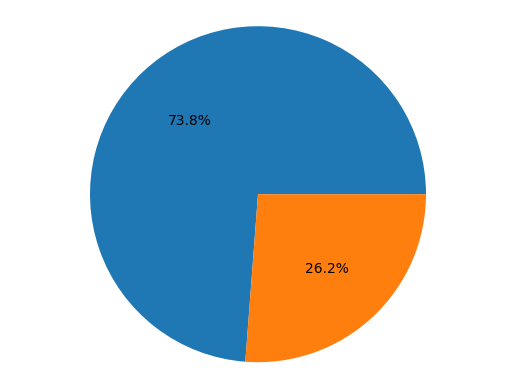

In [7]:
data.Churn.value_counts()

plt.pie(data.Churn.value_counts(), autopct='%1.1f%%')
plt.axis('equal')
plt.show()

Ушедших клиентов почти в 3 раза меньше, чем оставшихся — классы несбалансированы.

В качестве метрики качества используется **ROC-AUC**, а не accuracy, так как accuracy будет завышена из-за дисбаланса классов.

## 5. Анализ числовых признаков

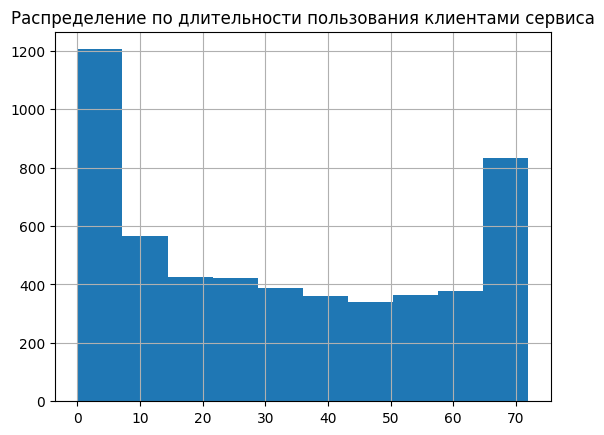

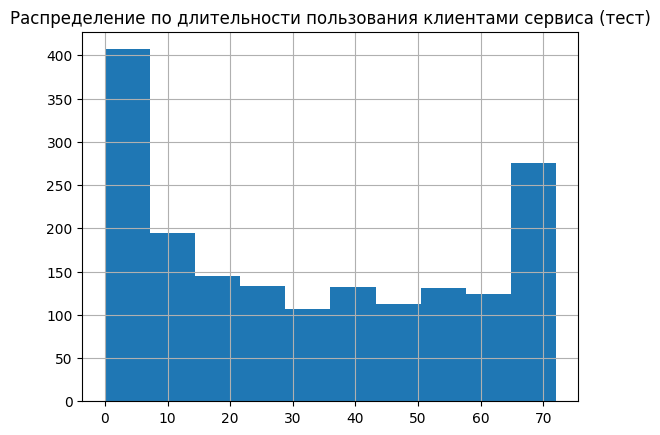

In [8]:
data.ClientPeriod.hist()
plt.title('Распределение по длительности пользования клиентами сервиса')
plt.show()

test.ClientPeriod.hist()
plt.title('Распределение по длительности пользования клиентами сервиса (тест)')
plt.show()

Распределения обучающей и тестовой выборок схожи.

Большая часть клиентов пользовалась услугами менее 10 дней, однако после 65 дней заметен всплеск по количеству пользователей.

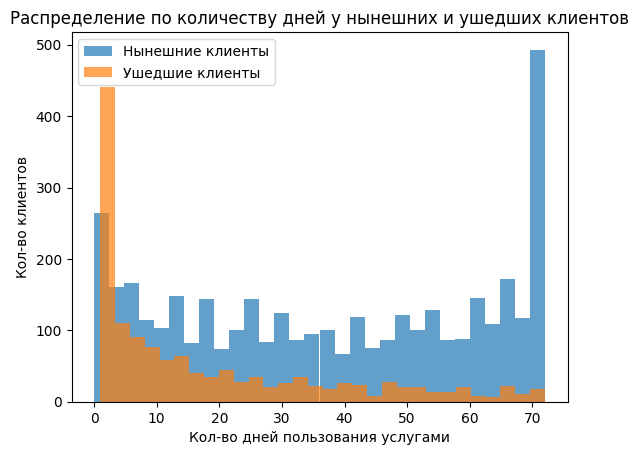

In [9]:
data.groupby('Churn')['ClientPeriod'].plot(kind='hist', bins=30, alpha=0.7)
plt.legend(['Нынешние клиенты', 'Ушедшие клиенты'])
plt.xlabel('Кол-во дней пользования услугами')
plt.ylabel('Кол-во клиентов')
plt.title('Распределение по количеству дней у нынешних и ушедших клиентов')
plt.show()

Большинство клиентов уходят в первые два дня пользования сервисом.

Это важный сигнал: высокий отток на раннем этапе может свидетельствовать о проблемах с онбордингом или несоответствии ожиданиям клиентов.

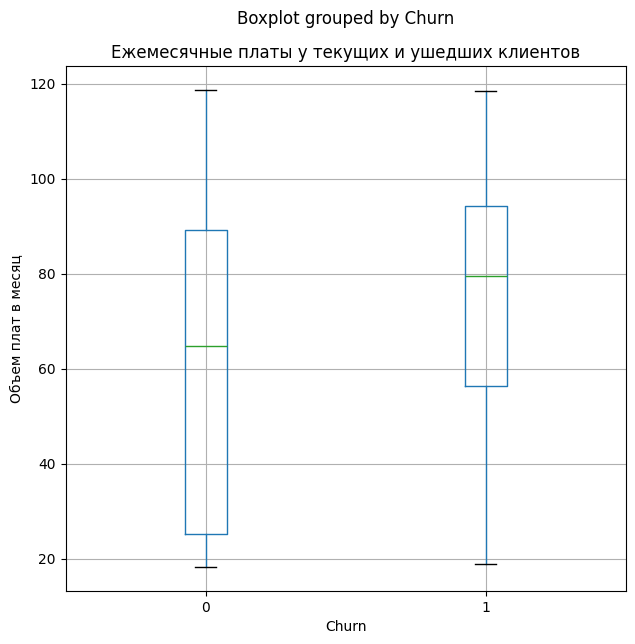

In [10]:
data.boxplot(column='MonthlySpending', by='Churn', figsize=(7,7))
plt.title('Ежемесячные платы у текущих и ушедших клиентов')
plt.xlabel('Churn')
plt.ylabel('Объем плат в месяц')
plt.show()

Медианное значение ежемесячных трат у ушедших клиентов (\~80) выше, чем у нынешних (\~60).

Клиенты с более высокой ежемесячной платой чаще уходят – возможно, они не считают услуги достаточно ценными для своей цены.

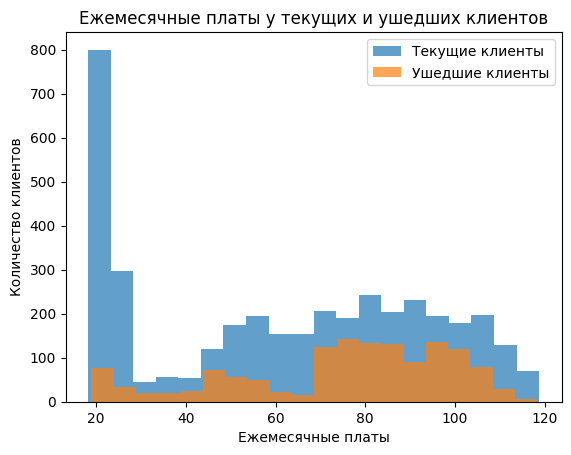

In [11]:
data.groupby('Churn')['MonthlySpending'].plot(kind='hist', bins=20, alpha=0.7)
plt.legend(['Текущие клиенты', 'Ушедшие клиенты'])
plt.xlabel('Ежемесячные платы')
plt.ylabel('Количество клиентов')
plt.title('Ежемесячные платы у текущих и ушедших клиентов')
plt.show()

Категория пользователей с низкой ежемесячной платой реже отказывалась от услуг компании.

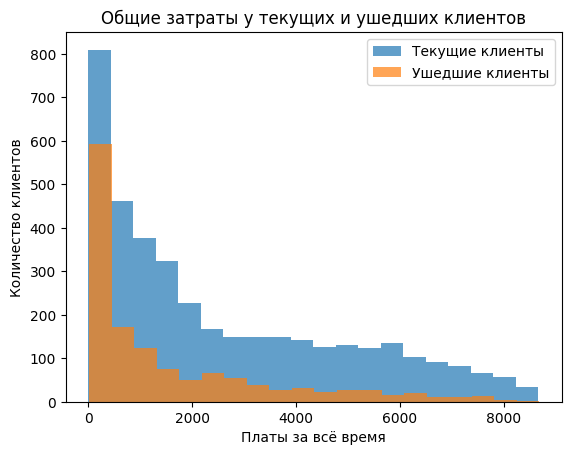

In [12]:
data.groupby('Churn')['TotalSpent'].plot(kind='hist', bins=20, alpha=0.7)
plt.legend(['Текущие клиенты', 'Ушедшие клиенты'])
plt.xlabel('Платы за всё время')
plt.ylabel('Количество клиентов')
plt.title('Общие затраты у текущих и ушедших клиентов')
plt.show()

Количество ушедших клиентов уменьшается с увеличением общих трат.

Клиенты, потратившие больше за всё время, реже уходят — вероятно, они более лояльны к компании.

## 6. Анализ категориальных признаков

/tmp/ipykernel_435/348948158.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_435/348948158.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_435/348948158.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_435/348948158.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_435/348948158.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

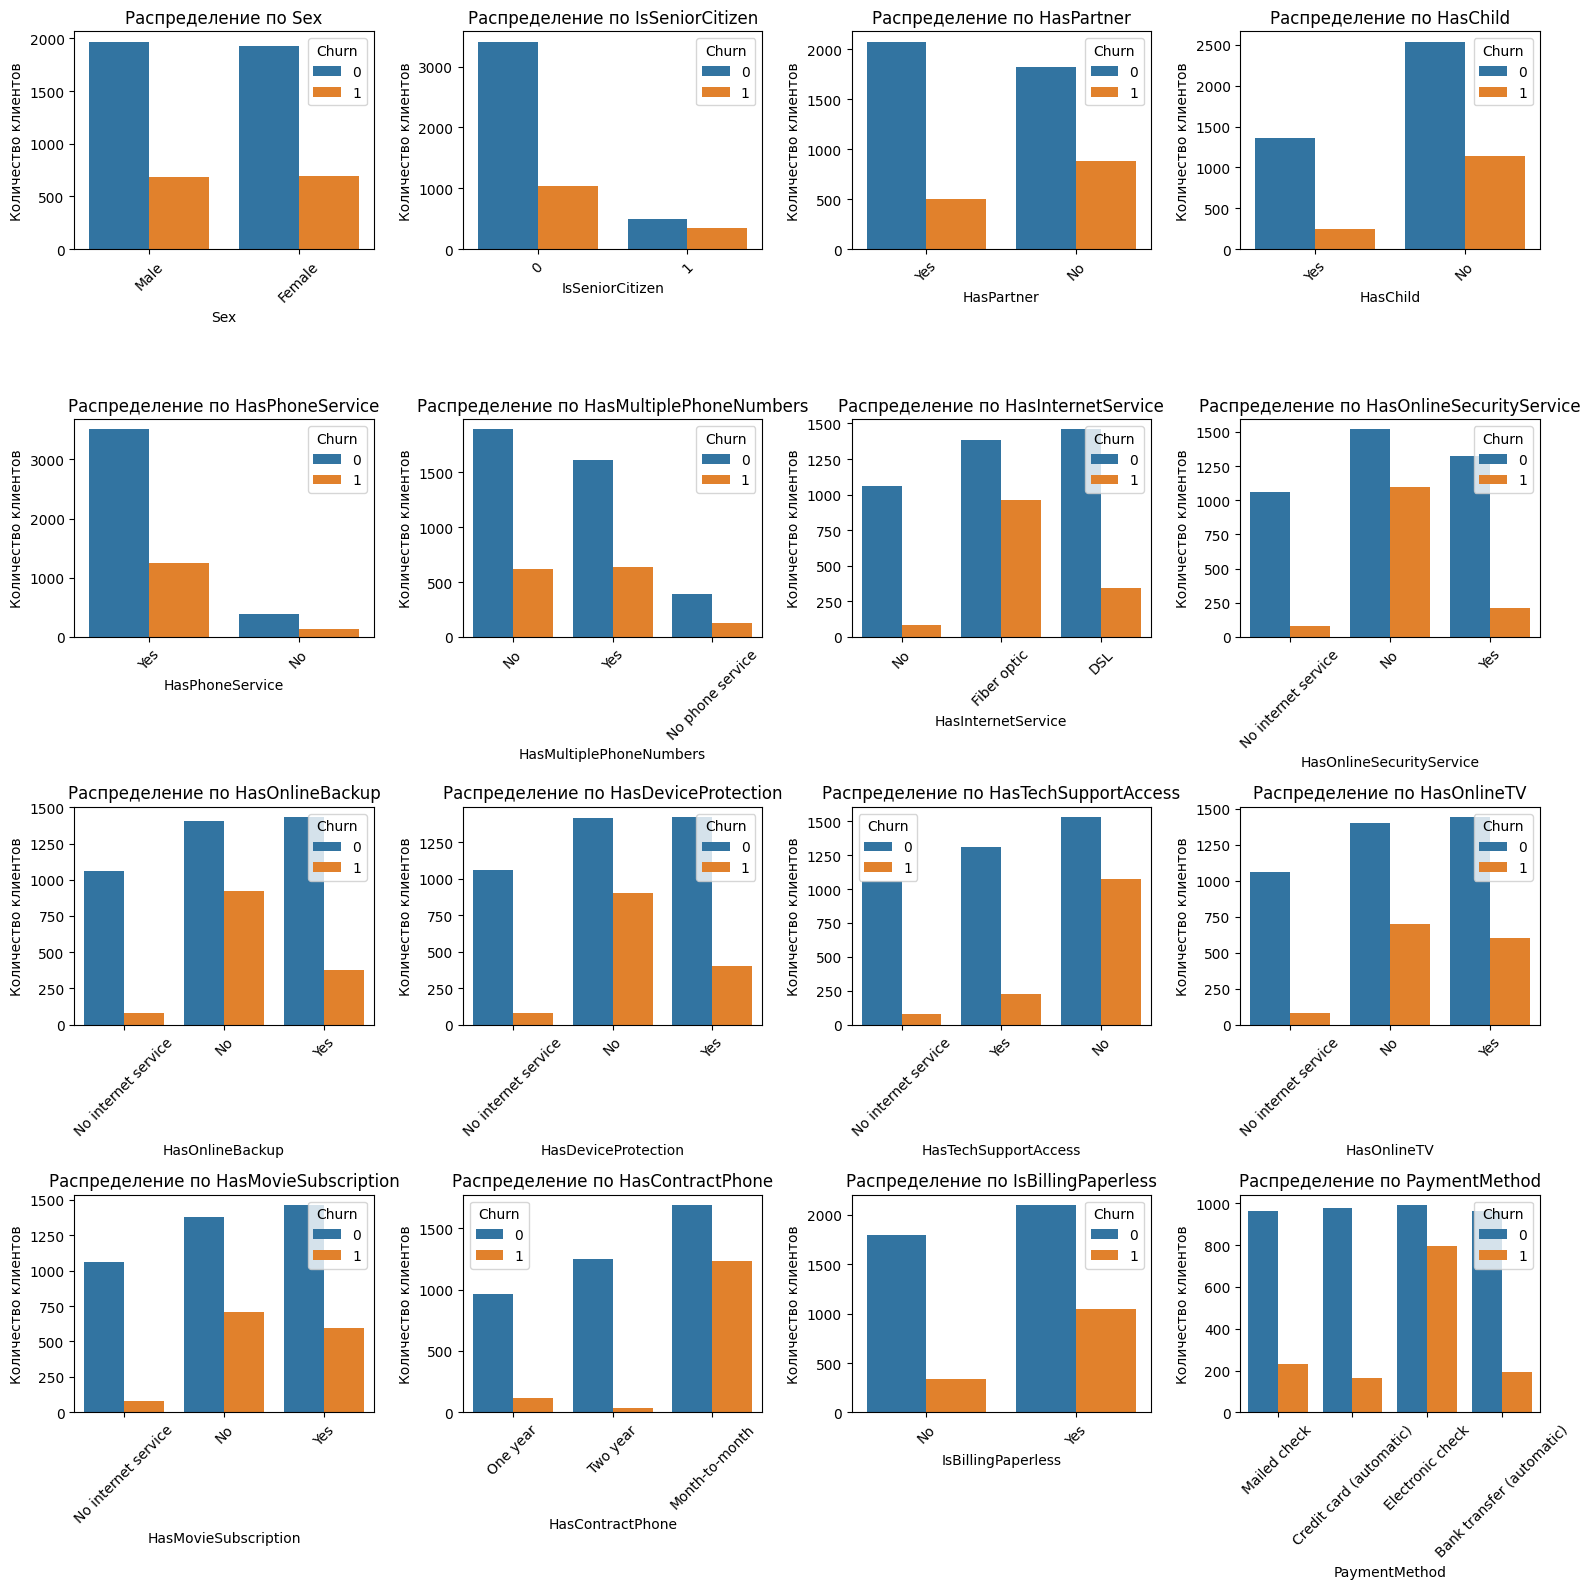

In [13]:
cat_cols = [
    'Sex', 'IsSeniorCitizen', 'HasPartner', 'HasChild',
    'HasPhoneService', 'HasMultiplePhoneNumbers', 'HasInternetService',
    'HasOnlineSecurityService', 'HasOnlineBackup', 'HasDeviceProtection',
    'HasTechSupportAccess', 'HasOnlineTV', 'HasMovieSubscription',
    'HasContractPhone', 'IsBillingPaperless', 'PaymentMethod'
]

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 16))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

for i, feature in enumerate(cat_cols):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    sns.countplot(x=feature, hue='Churn', data=data, ax=ax)
    ax.set_xlabel(feature)
    ax.set_ylabel('Количество клиентов')
    ax.set_title(f'Распределение по {feature}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

По результатам анализа категориальных признаков:

- Среди ушедших клиентов чаще встречается **Fiber Optic Internet** и **Online Security Service**.

- Ушедшие клиенты чаще имели **партнёра и детей**, чем нынешние.

- Ушедшие клиенты чаще заключали **контракт на месяц** — краткосрочные контракты связаны с более высоким оттоком.

- Среди ушедших клиентов чаще **отсутствовали услуги Online Backup и DeviceProtection**.

- Компанией одинаково пользуются как мужчины, так и женщины — пол не является значимым фактором оттока.

## 7. Матрица корреляций

interval columns not set, guessing: ['ClientPeriod', 'MonthlySpending', 'TotalSpent', 'IsSeniorCitizen', 'Churn']


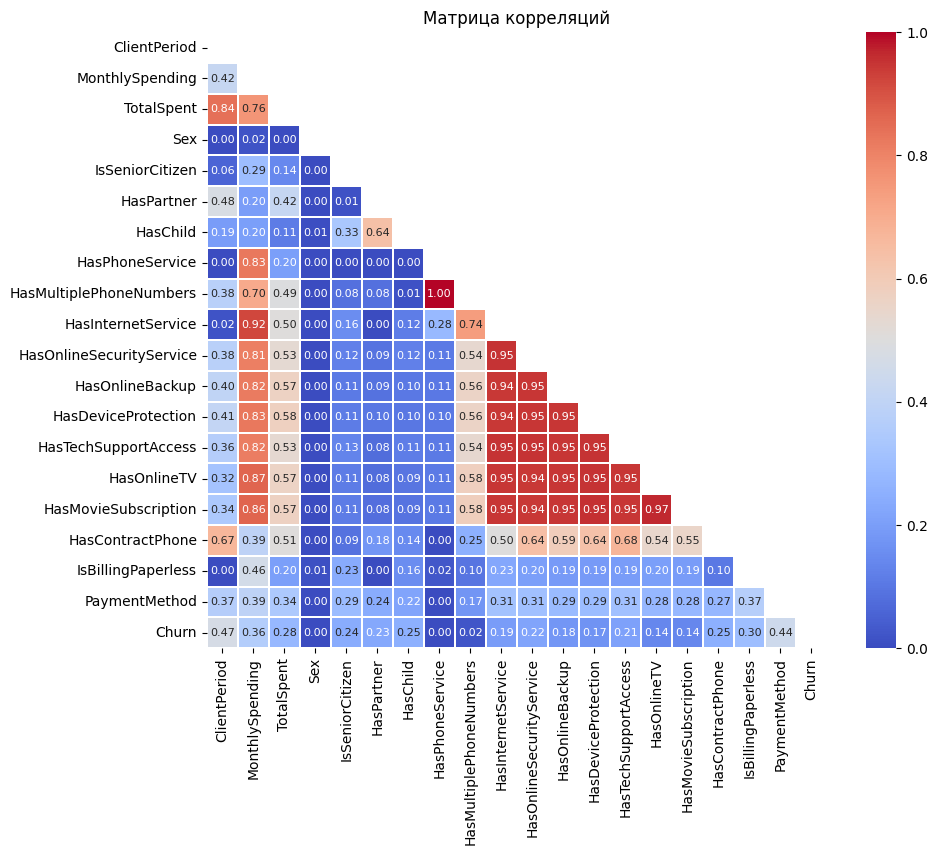

In [14]:
corr_data = data.phik_matrix()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, annot=True, cmap="coolwarm",
            fmt=".2f", annot_kws={"size": 8}, linewidths=0.2)
plt.title("Матрица корреляций")
plt.xticks(rotation=90)
plt.show()

Между всеми услугами наблюдается сильная корреляция.

`ClientPeriod` сильно коррелирует с `TotalSpent`, а `MonthlySpending` — со всеми услугами.

Для предотвращения мультиколлинеарности удаляем признаки с сильной корреляцией с `MonthlySpending`: `HasInternetService`, `HasOnlineTV`, `HasMovieSubscription`.

In [16]:
data_clean = data.drop(['HasInternetService', 'HasOnlineTV', 'HasMovieSubscription'], axis=1)
test_clean = test.drop(['HasInternetService', 'HasOnlineTV', 'HasMovieSubscription'], axis=1)

features_train = data.drop('Churn', axis=1)
target_train = data.Churn

features_train_cl = data_clean.drop('Churn', axis=1)
target_train_cl = data_clean.Churn

num_cols = ['ClientPeriod', 'MonthlySpending', 'TotalSpent']

cat_features = [
    'Sex', 'IsSeniorCitizen', 'HasPartner', 'HasChild',
    'HasPhoneService', 'HasMultiplePhoneNumbers', 'HasContractPhone',
    'IsBillingPaperless', 'PaymentMethod', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
]

## 8. Обучение моделей

### 8.1 Логистическая регрессия

In [17]:
results = {}

cat_transformer = Pipeline(steps=[('ohe', OneHotEncoder(drop='first', handle_unknown='error'))])
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

preprocessing = ColumnTransformer(transformers=[
    ('cat', cat_transformer, cat_features),
    ('num', num_transformer, num_cols),
])

regression_pipe = Pipeline(steps=[('preprocessor', preprocessing),
                                   ('model', LogisticRegression())])

param_grid = {'model__C': [100, 10, 1, 0.1, 0.01, 0.001],
              'model__penalty': ['l1', 'l2'],
              'model__solver': ['liblinear', 'saga'],
              'model__max_iter': [100, 500, 1000]}

regression_cv = RandomizedSearchCV(regression_pipe, param_grid, cv=5,
                                   scoring='roc_auc', n_iter=15, random_state=321)
regression_cv.fit(features_train_cl, target_train_cl)

results['LogisticRegression'] = regression_cv.best_score_
print("ROC-AUC:", regression_cv.best_score_)

ROC-AUC: 0.8449107516459037


### 8.2 Случайный лес

In [18]:
cat_transformer = Pipeline(steps=[
    ('ordinal_encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

preprocessing = ColumnTransformer(transformers=[
    ('cat', cat_transformer, cat_cols),
    ('num', num_transformer, num_cols),
])

forest_pipe = Pipeline(steps=[('preprocessor', preprocessing),
                               ('model', RandomForestClassifier(random_state=321))])

forest_params = {
    'model__max_depth': range(1, 10, 1),
    'model__max_features': [None, "sqrt", "log2"],
    'model__n_estimators': [100, 150, 200],
    'model__min_samples_leaf': range(2, 8, 1),
    'model__min_samples_split': [3, 5, 10]
}

forest_cv = RandomizedSearchCV(forest_pipe, forest_params, cv=5, random_state=321,
                               scoring='roc_auc', n_iter=15, n_jobs=-1)
forest_cv.fit(features_train, target_train)

results['RandomForest'] = forest_cv.best_score_
print("ROC-AUC:", forest_cv.best_score_)

ROC-AUC: 0.8447685510447668


### 8.3 CatBoost Default

In [21]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)
scores = []

for train_idx, val_idx in kf.split(features_train, target_train):
    X_tr, X_val = features_train.iloc[train_idx], features_train.iloc[val_idx]
    y_tr, y_val = target_train.iloc[train_idx], target_train.iloc[val_idx]

    model = CatBoostClassifier(cat_features=cat_cols, verbose=0)
    model.fit(X_tr, y_tr)
    pred = model.predict_proba(X_val)[:, 1]
    scores.append(roc_auc_score(y_val, pred))

result = np.mean(scores)
results['CatBoost Default'] = result
print("ROC-AUC:", result)

ROC-AUC: 0.8411169167676474


 ### 8.4 CatBoost с подбором гиперпараметров (CV)

In [23]:
from sklearn.model_selection import StratifiedKFold
from itertools import product
import random

random.seed(321)

params = {
    'depth': [2, 3, 4, 5],
    'l2_leaf_reg': [0.1, 0.5, 1, 5, 10],
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.3, 0.4]
}

# случайные 15 комбинаций параметров
keys = list(params.keys())
all_combinations = list(product(*params.values()))
random_combinations = random.sample(all_combinations, 15)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)
best_score = 0
best_params = {}

for combo in random_combinations:
    current_params = dict(zip(keys, combo))
    scores = []

    for train_idx, val_idx in kf.split(features_train, target_train):
        X_tr = features_train.iloc[train_idx]
        X_val = features_train.iloc[val_idx]
        y_tr = target_train.iloc[train_idx]
        y_val = target_train.iloc[val_idx]

        model = CatBoostClassifier(
            **current_params,
            cat_features=cat_cols,
            verbose=0
        )
        model.fit(X_tr, y_tr)
        pred = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, pred))

    mean_score = np.mean(scores)
    if mean_score > best_score:
        best_score = mean_score
        best_params = current_params

results['CatBoost CV'] = best_score
print("Лучшие параметры:", best_params)
print("ROC-AUC:", best_score)

Лучшие параметры: {'depth': 3, 'l2_leaf_reg': 0.5, 'n_estimators': 500, 'learning_rate': 0.01}
ROC-AUC: 0.8454800853981345


## 9. Сравнение моделей

In [25]:
results_series = pd.Series(results)
print(results_series)

LogisticRegression    0.844911
RandomForest          0.844769
CatBoost Default      0.841117
CatBoost CV           0.845480
dtype: float64


Наилучший результат по метрике ROC-AUC показал **CatBoost с подбором гиперпараметров**.

CatBoost эффективно справляется с категориальными признаками без их предварительного кодирования, что является его ключевым преимуществом для данного датасета.

## 10. Обучение финальной модели

In [27]:
best_model = CatBoostClassifier(
    **best_params,
    cat_features=cat_cols,
    verbose=0
)
best_model.fit(features_train, target_train)
print("Модель обучена")

Модель обучена


## Вывод

В ходе работы были применены три алгоритма классификации для прогнозирования оттока клиентов.

Наилучшую производительность продемонстрировал **CatBoost** — он превзошёл логистическую регрессию и случайный лес по метрике ROC-AUC.

Ключевые факторы, влияющие на отток клиентов:

- Короткий срок пользования сервисом — большинство уходят в первые два дня.

- Высокая ежемесячная плата.

- Краткосрочный контракт (помесячный).

- Отсутствие дополнительных услуг (Online Backup, DeviceProtection).

Результаты могут быть использованы для разработки стратегий удержания клиентов.